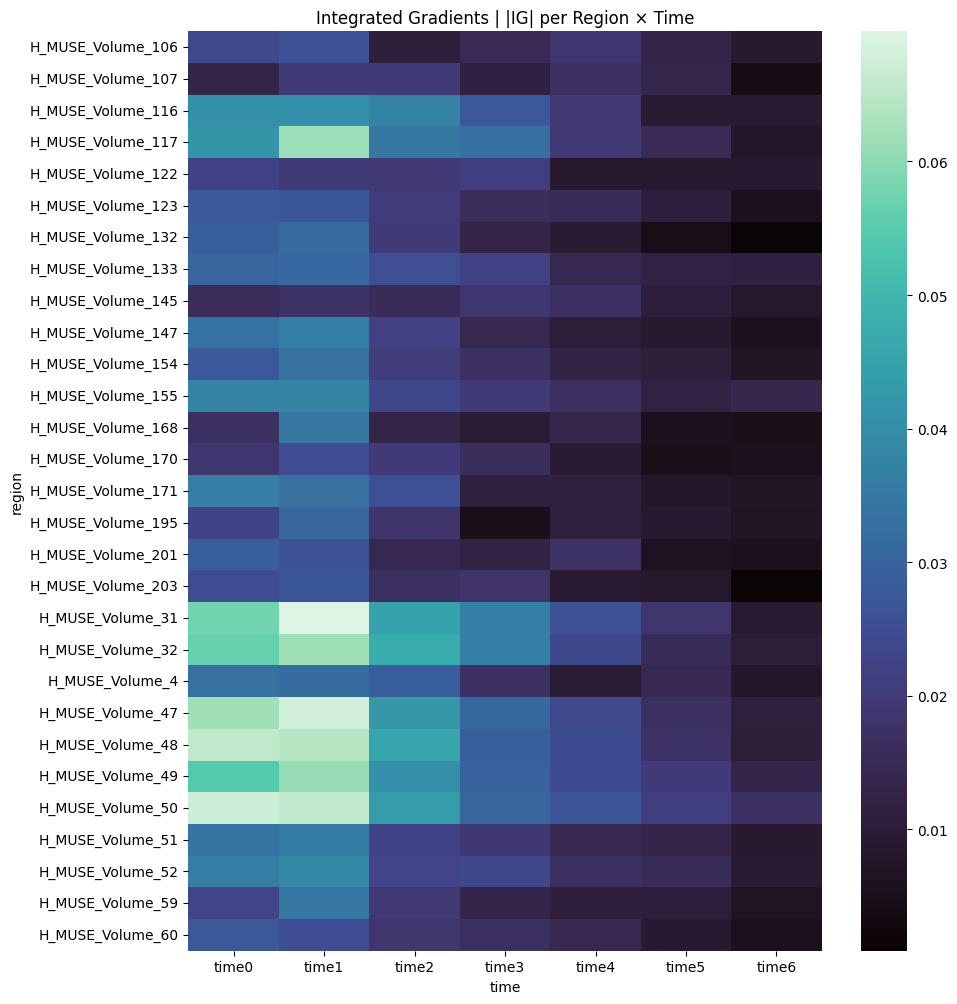

In [20]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

summary = pd.read_csv("thesis-ad-diagnosis/tralzformer/advsrest/tralzformer_september/model_predictions/7_Visits/Exp_07_09_DiagnosisPredictionFinal_9V_fold_1_Preds_ig_summary.csv")
summary = summary[summary["region"] != "Age"]  
#summary = pd.read_csv("model_predictions/Modality_B_03_09_02_Old_Sol_fold_1_Preds_ig_summary.csv")
pivot = summary.pivot(index="region", columns="time", values="abs_mean").fillna(0)
plt.figure(figsize=(10, max(6, 0.35*len(pivot))))
sns.heatmap(pivot, cmap="mako", annot=False)
plt.title("Integrated Gradients | |IG| per Region × Time")
plt.tight_layout(); plt.show()

In [31]:
import numpy as np

def top_k_regions_per_time(
    summary_csv: str | pd.DataFrame,
    metric: str = "abs_mean",    # "abs_mean" (importance) or "mean" (directional)
    k: int = 10,
    min_count: int | None = None,
    time_col: str = "time",
    region_col: str = "region"
) -> pd.DataFrame:
    """
    Return the top-k regions per time step by `metric`.
    Expects columns: region, time, metric, (optional) count.
    """

    # --- Load ---
    df = pd.read_csv(summary_csv) if isinstance(summary_csv, str) else summary_csv.copy()

    df = df[df["region"] != "Age"]  

    # --- Sanity checks ---
    for col in [time_col, region_col, metric]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}'. Found: {list(df.columns)}")

    # --- Optional: filter by minimum sample count ---
    if min_count is not None and "count" in df.columns:
        df = df[df["count"] >= min_count].copy()

    # --- Coerce time to numeric (handles 'time0', 't6', etc.) ---
    if not np.issubdtype(df[time_col].dtype, np.number):
        extracted = pd.to_numeric(
            df[time_col].astype(str).str.extract(r"(\d+)")[0],
            errors="coerce"
        )
        # If extraction fails everywhere, keep original; else use numeric
        if extracted.notna().any():
            df[time_col] = extracted

    # --- Coerce metric to numeric & drop NaNs in metric ---
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric])

    if df.empty:
        raise ValueError("No rows left after filtering/coercion. Check `min_count` and column names/types.")

    # --- Sort and take top-k per time ---
    df_sorted = df.sort_values([time_col, metric], ascending=[True, False])
    topk = (df_sorted
            .groupby(time_col, group_keys=True, sort=True)
            .head(k)
            .copy())

    # --- Add rank within each time ---
    topk["rank"] = (topk.groupby(time_col)
                         .cumcount()
                         .add(1))

    # --- Nice column name for the metric ---
    topk = topk.rename(columns={metric: f"{metric}_score"})

    # --- Reorder columns ---
    keep_cols = [time_col, "rank", region_col, f"{metric}_score"]
    if "count" in topk.columns:
        keep_cols.append("count")
    # Keep any other columns too, but show the essentials first
    other_cols = [c for c in topk.columns if c not in keep_cols]
    topk = topk[keep_cols + other_cols].sort_values([time_col, "rank"]).reset_index(drop=True)

    return topk

# ---- usage ----
summary_path = "thesis-ad-diagnosis/tralzformer/advsrest/tralzformer_september/model_predictions/7_Visits/Exp_07_09_DiagnosisPredictionFinal_9V_fold_5_Preds_ig_summary.csv"
#summary_path = "model_predictions/Modality_B_03_09_02_Old_Sol_fold_1_Preds_ig_summary.csv"
top10_abs = top_k_regions_per_time(summary_path, metric="abs_mean", k=10, min_count=30)
print(top10_abs.head(100))

# Save for your report
top10_abs.to_csv("thesis-ad-diagnosis/tralzformer/advsrest/tralzformer_september/model_predictions/top10_regions_per_time_abs_mean_fold5.csv", index=False)

# If you want the *directional* (signed) winners instead of absolute importance:
top10_signed = top_k_regions_per_time(summary_path, metric="mean", k=10, min_count=30)
top10_signed.to_csv("thesis-ad-diagnosis/tralzformer/advsrest/tralzformer_september/model_predictions/top10_regions_per_time_signed_mean.csv", index=False)

# (Optional) make a compact wide table listing just the region names per time & rank
def to_wide_names(topk_df: pd.DataFrame) -> pd.DataFrame:
    names = (topk_df
             .pivot_table(index="time", columns="rank", values="region", aggfunc="first")
             .rename(columns=lambda r: f"Top{r}"))
    return names.reset_index()

wide_abs = to_wide_names(top10_abs)
wide_abs.to_csv("thesis-ad-diagnosis/tralzformer/advsrest/tralzformer_september/model_predictions/top10_regions_names_per_time_abs.csv", index=False)
print(wide_abs.head())

    time  rank             region  abs_mean_score  count      mean       std
0      0     1   H_MUSE_Volume_48        0.074525    479 -0.011928  0.094800
1      0     2   H_MUSE_Volume_49        0.068928    479 -0.018182  0.085421
2      0     3   H_MUSE_Volume_47        0.065394    479 -0.010486  0.079757
3      0     4   H_MUSE_Volume_50        0.058236    479 -0.013871  0.075011
4      0     5   H_MUSE_Volume_31        0.055738    479 -0.006148  0.070633
..   ...   ...                ...             ...    ...       ...       ...
65     6     6  H_MUSE_Volume_108        0.012598    479 -0.002485  0.031433
66     6     7  H_MUSE_Volume_133        0.011633    479  0.002117  0.028786
67     6     8  H_MUSE_Volume_155        0.011461    479  0.002123  0.028822
68     6     9  H_MUSE_Volume_182        0.011168    479 -0.000963  0.031240
69     6    10  H_MUSE_Volume_170        0.010088    479  0.002459  0.025831

[70 rows x 7 columns]
rank  time              Top1              Top2       

In [23]:
import numpy as np

def top_k_regions_per_time(
    summary_csv: str | pd.DataFrame,
    metric: str = "abs_mean",    # "abs_mean" (importance) or "mean" (directional)
    k: int = 10,
    min_count: int | None = None,
    time_col: str = "time",
    region_col: str = "region"
) -> pd.DataFrame:
    """
    Return the top-k regions per time step by `metric`.
    Expects columns: region, time, metric, (optional) count.
    """

    # --- Load ---
    df = pd.read_csv(summary_csv) if isinstance(summary_csv, str) else summary_csv.copy()

    df = df[df["region"] != "Age"]  

    # --- Sanity checks ---
    for col in [time_col, region_col, metric]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}'. Found: {list(df.columns)}")

    # --- Optional: filter by minimum sample count ---
    if min_count is not None and "count" in df.columns:
        df = df[df["count"] >= min_count].copy()

    # --- Coerce time to numeric (handles 'time0', 't6', etc.) ---
    if not np.issubdtype(df[time_col].dtype, np.number):
        extracted = pd.to_numeric(
            df[time_col].astype(str).str.extract(r"(\d+)")[0],
            errors="coerce"
        )
        # If extraction fails everywhere, keep original; else use numeric
        if extracted.notna().any():
            df[time_col] = extracted

    # --- Coerce metric to numeric & drop NaNs in metric ---
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric])

    if df.empty:
        raise ValueError("No rows left after filtering/coercion. Check `min_count` and column names/types.")

    # --- Sort and take top-k per time ---
    df_sorted = df.sort_values([time_col, metric], ascending=[True, False])
    topk = (df_sorted
            .groupby(time_col, group_keys=True, sort=True)
            .head(k)
            .copy())

    # --- Add rank within each time ---
    topk["rank"] = (topk.groupby(time_col)
                         .cumcount()
                         .add(1))

    # --- Nice column name for the metric ---
    topk = topk.rename(columns={metric: f"{metric}_score"})

    # --- Reorder columns ---
    keep_cols = [time_col, "rank", region_col, f"{metric}_score"]
    if "count" in topk.columns:
        keep_cols.append("count")
    # Keep any other columns too, but show the essentials first
    other_cols = [c for c in topk.columns if c not in keep_cols]
    topk = topk[keep_cols + other_cols].sort_values([time_col, "rank"]).reset_index(drop=True)

    return topk

# ---- usage ----
fold = 4
summary_path = f"tralzformer_september/model_predictions/07_09_Cluster1_11_09/Exp_07_09_DiagnosisPredictionFinal_Cluster1_7V_fold_{fold}_Preds_ig_summary.csv"
#summary_path = "model_predictions/Modality_B_03_09_02_Old_Sol_fold_1_Preds_ig_summary.csv"
top10_abs = top_k_regions_per_time(summary_path, metric="abs_mean", k=10, min_count=30)
print(top10_abs.head(100))

# Save for your report
top10_abs.to_csv(f"tralzformer_september/model_predictions/07_09_Cluster1_11_09/IG/top10_regions_per_time_abs_mean_fold{fold}.csv", index=False)

# If you want the *directional* (signed) winners instead of absolute importance:
top10_signed = top_k_regions_per_time(summary_path, metric="mean", k=10, min_count=30)
top10_signed.to_csv(f"tralzformer_september/model_predictions/07_09_Cluster1_11_09/IG/top10_regions_per_time_signed_mean_fold{fold}.csv", index=False)

# (Optional) make a compact wide table listing just the region names per time & rank
def to_wide_names(topk_df: pd.DataFrame) -> pd.DataFrame:
    names = (topk_df
             .pivot_table(index="time", columns="rank", values="region", aggfunc="first")
             .rename(columns=lambda r: f"Top{r}"))
    return names.reset_index()

wide_abs = to_wide_names(top10_abs)
wide_abs.to_csv(f"tralzformer_september/model_predictions/07_09_Cluster1_11_09/IG/top10_regions_names_per_time_abs_fold{fold}.csv", index=False)
print(wide_abs.head())

    time  rank             region  abs_mean_score  count      mean       std
0      0     1   H_MUSE_Volume_48        0.086264     66  0.052231  0.093026
1      0     2   H_MUSE_Volume_49        0.080332     66  0.064075  0.097113
2      0     3   H_MUSE_Volume_50        0.079461     66  0.063308  0.087074
3      0     4   H_MUSE_Volume_47        0.074475     66  0.035161  0.082052
4      0     5   H_MUSE_Volume_32        0.062329     66  0.033753  0.069446
..   ...   ...                ...             ...    ...       ...       ...
65     6     6   H_MUSE_Volume_31        0.020089     66  0.019357  0.043571
66     6     7  H_MUSE_Volume_117        0.018151     66  0.015950  0.039254
67     6     8   H_MUSE_Volume_32        0.017935     66  0.017515  0.037628
68     6     9   H_MUSE_Volume_48        0.017761     66  0.015204  0.040926
69     6    10  H_MUSE_Volume_122        0.017394     66  0.006951  0.037229

[70 rows x 7 columns]
rank  time              Top1               Top2      

In [25]:
import pandas as pd
from pathlib import Path

# --- Point these to your per-fold CSVs (the ones you pasted) ---
# If each fold is saved separately, list them here in any order:
files = [
    "tralzformer_september/model_predictions/07_09_Cluster0/IG/top10_regions_per_time_abs_mean_fold1.csv",
    "tralzformer_september/model_predictions/07_09_Cluster0/IG/top10_regions_per_time_abs_mean_fold2.csv",
    "tralzformer_september/model_predictions/07_09_Cluster0/IG/top10_regions_per_time_abs_mean_fold3.csv",
    "tralzformer_september/model_predictions/07_09_Cluster0/IG/top10_regions_per_time_abs_mean_fold4.csv",
    "tralzformer_september/model_predictions/07_09_Cluster0/IG/top10_regions_per_time_abs_mean_fold5.csv",
]

# Read & concat
df = pd.concat([pd.read_csv(p) for p in files], ignore_index=True)

# Optional: if you kept 'Age' in some summaries and want to exclude it from interpretability:
# df = df[df["region"] != "Age"]

# Aggregate across folds & time: mean abs_mean_score per region
agg = (
    df.groupby("region", as_index=False)
      .agg(
          abs_mean_overall=("abs_mean_score", "mean"),
          appearances=("abs_mean_score", "size")  # how many (fold,time,rank) entries contributed
      )
      .sort_values("appearances", ascending=False)
)

top10 = agg.head(10).reset_index(drop=True)

# Neat display
print(top10)

# Optional: LaTeX table you can paste into the thesis
latex = [
    r"\begin{table}[H]",
    r"\centering",
    r"\caption{Top 10 regions by mean $|$IG$|$ across folds and time}",
    r"\label{tab:ig_top10_overall}",
    r"\resizebox{0.7\textwidth}{!}{",
    r"\begin{tabular}{l c c}",
    r"\hline",
    r"\textbf{Region} & \textbf{Mean $|$IG$|$} & \textbf{Appearances} \\",
    r"\hline",
]

for _, row in top10.iterrows():
    latex.append(f"{row['region']} & {row['abs_mean_overall']:.4f} & {int(row['appearances'])} \\\\")
latex += [
    r"\hline",
    r"\end{tabular}",
    r"}",
    r"\end{table}",
]
print("\n".join(latex))

              region  abs_mean_overall  appearances
0   H_MUSE_Volume_50          0.038076           35
1   H_MUSE_Volume_49          0.036843           35
2   H_MUSE_Volume_47          0.038826           34
3   H_MUSE_Volume_48          0.039832           34
4  H_MUSE_Volume_117          0.039333           30
5   H_MUSE_Volume_31          0.045197           28
6   H_MUSE_Volume_32          0.041536           28
7  H_MUSE_Volume_116          0.038882           25
8  H_MUSE_Volume_155          0.030614           16
9   H_MUSE_Volume_52          0.028608           12
\begin{table}[H]
\centering
\caption{Top 10 regions by mean $|$IG$|$ across folds and time}
\label{tab:ig_top10_overall}
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{l c c}
\hline
\textbf{Region} & \textbf{Mean $|$IG$|$} & \textbf{Appearances} \\
\hline
H_MUSE_Volume_50 & 0.0381 & 35 \\
H_MUSE_Volume_49 & 0.0368 & 35 \\
H_MUSE_Volume_47 & 0.0388 & 34 \\
H_MUSE_Volume_48 & 0.0398 & 34 \\
H_MUSE_Volume_117 & 0.0393 & 30 \\
H_